### 1. Вступ та очищення даних
Для виконання лабораторної роботи було обрано датасет **Automobile** з репозиторію UCI. Цей набір даних ідеально підходить під вимоги, оскільки він є багатовимірним, містить як числові, так і категоріальні ознаки, а також має пропущені значення (позначені як `?`).

У процесі підготовки даних було виконано:
* Заміну символів `?` на стандартні значення `NaN`.
* Заповнення пропусків у числових колонках (**normalized-losses**, **horsepower** тощо) за допомогою медіани, що дозволяє зберегти структуру даних без впливу екстремальних викидів.
* Видалення об'єктів з пропущеною ціною, оскільки цей атрибут є ключовим для подальшого аналізу.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors", 
           "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width", 
           "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size", 
           "fuel-system", "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm", 
           "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=headers, na_values="?")

for col in ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']:
    df[col] = df[col].fillna(df[col].median())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])
df.dropna(subset=['price'], inplace=True)
df['price'] = df['price'].astype(int)

print(f"Дані успішно завантажено та очищено. Розмір датасету: {df.shape}")

Дані успішно завантажено та очищено. Розмір датасету: (201, 26)


### 2. Аналіз залежності ціни від ваги (Scatter Plot)
Згідно із завданням, побудовано графік залежності між двома числовими атрибутами: **curb-weight** (вага авто) та **price** (ціна). Використання лінії регресії дозволяє чітко побачити позитивний тренд: зі збільшенням маси автомобіля його вартість зазвичай зростає, що пояснюється використанням більшої кількості матеріалів та складніших вузлів агрегатів.

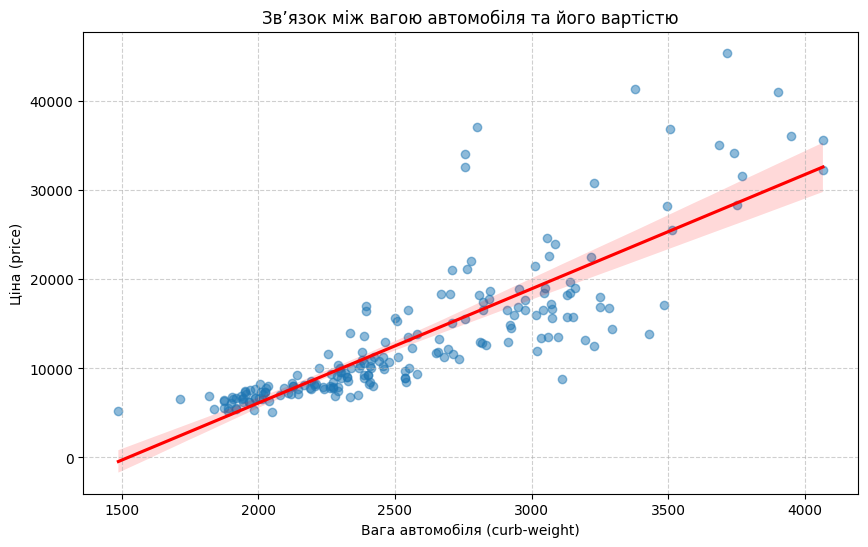

In [5]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='curb-weight', y='price', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Зв’язок між вагою автомобіля та його вартістю')
plt.xlabel('Вага автомобіля (curb-weight)')
plt.ylabel('Ціна (price)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3. Розподіл економічності пального (Гістограма з 5 діапазонами)
Для виконання вимоги щодо побудови гістограми рівно з 5 діапазонами було обрано атрибут **highway-mpg**. Весь спектр значень витрати пального на трасі було розбито на п'ять рівних відрізків. Це дозволяє наочно побачити, що більшість автомобілів у вибірці зосереджена в середньому діапазоні економічності.

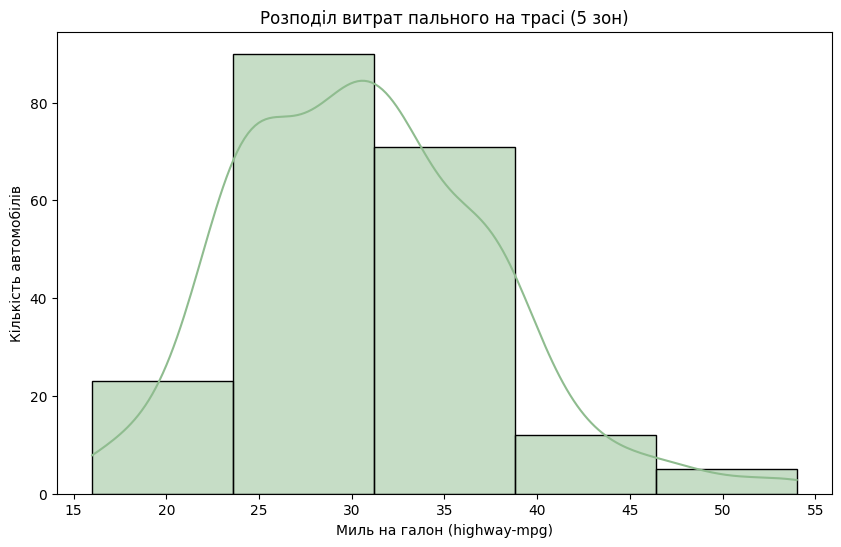

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['highway-mpg'], bins=5, color='darkseagreen', kde=True)
plt.title('Розподіл витрат пального на трасі (5 зон)')
plt.xlabel('Миль на галон (highway-mpg)')
plt.ylabel('Кількість автомобілів')
plt.show()

### 4. Багатовимірний аналіз характеристик
Ця візуалізація побудована з використанням методів відображення багатовимірних даних. На одному графіку поєднано одразу чотири параметри:
* **Осі X та Y:** Потужність (**horsepower**) та ціна (**price**).
* **Колір (hue):** Тип приводу (**drive-wheels**).
* **Розмір точок (size):** Об'єм двигуна (**engine-size**), що додає розуміння технічної потужності кожного авто.

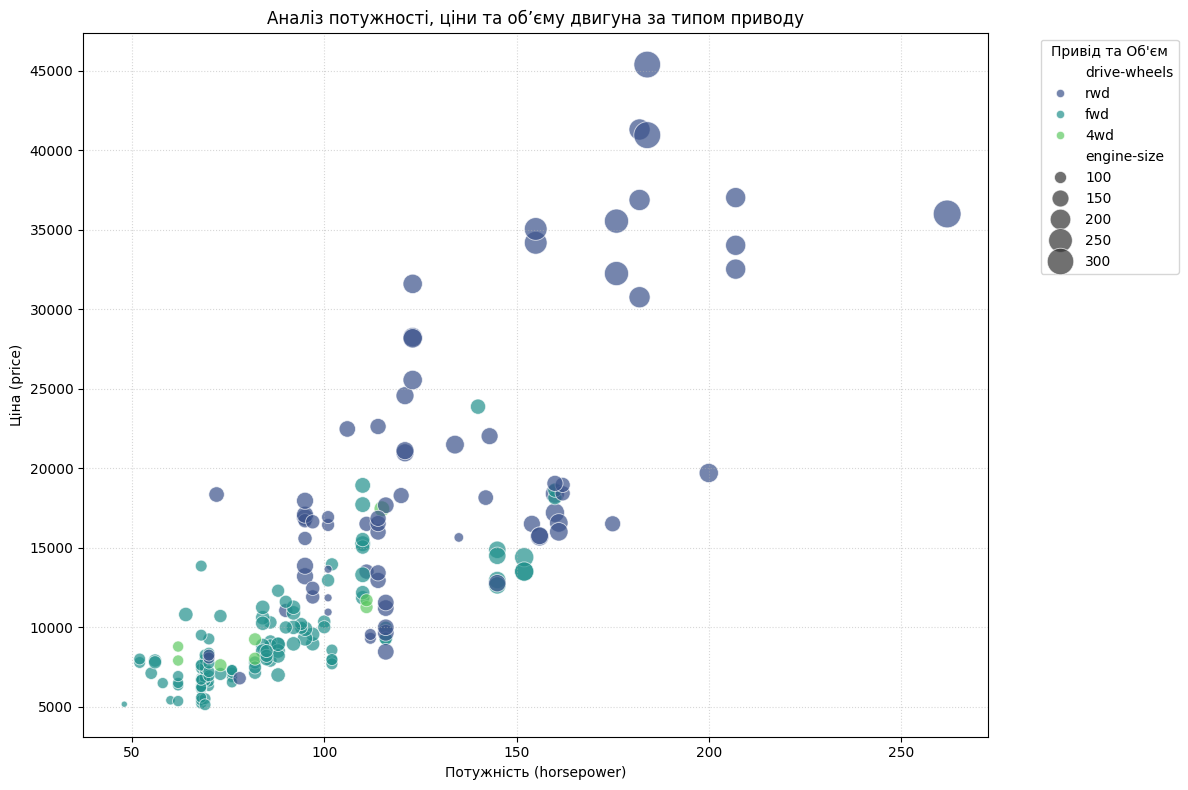

In [7]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='horsepower', y='price', hue='drive-wheels', size='engine-size', 
                sizes=(20, 400), palette='viridis', alpha=0.7)
plt.title('Аналіз потужності, ціни та об’єму двигуна за типом приводу')
plt.xlabel('Потужність (horsepower)')
plt.ylabel('Ціна (price)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title='Привід та Об\'єм')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 5. Аналіз цін за типом кузова (Boxplot + Swarmplot)
Для отримання додаткової корисної інформації створено комбінований графік. Використання **Boxplot** показує медіану та квартилі, а накладений зверху **Swarmplot** відображає кожне конкретне спостереження.

C:\Users\Click\AppData\Local\Temp\ipykernel_20456\545421716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='body-style', y='price', palette='Set3')


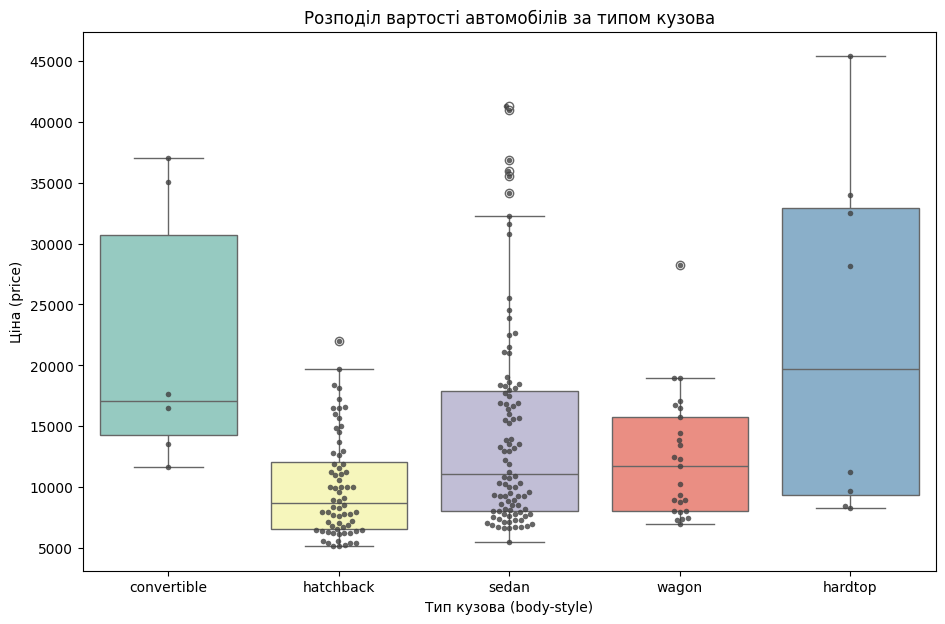

In [8]:
plt.figure(figsize=(11, 7))
sns.boxplot(data=df, x='body-style', y='price', palette='Set3')
sns.swarmplot(data=df, x='body-style', y='price', color='0.25', size=4, alpha=0.8)
plt.title('Розподіл вартості автомобілів за типом кузова')
plt.xlabel('Тип кузова (body-style)')
plt.ylabel('Ціна (price)')
plt.show()

### 6. Матриця кореляції (Теплова карта)
Побудовано теплову карту кореляції Пірсона для ключових числових ознак. Це допомагає ідентифікувати найсильніші зв'язки в датасеті (наприклад, між габаритами авто та його вагою, або об'ємом двигуна та ціною).

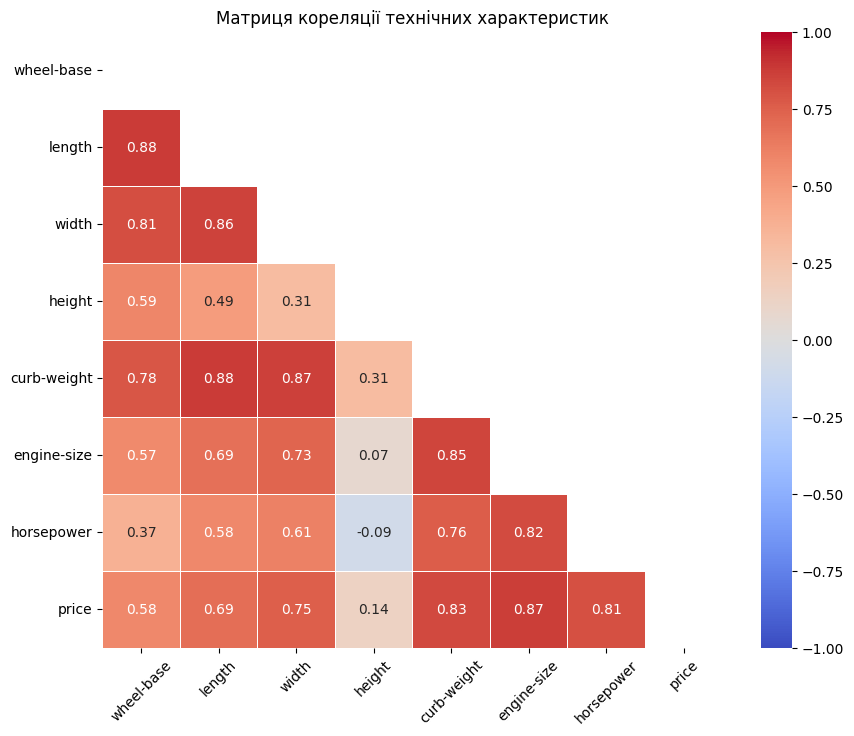

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[['wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'horsepower', 'price']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матриця кореляції технічних характеристик')
plt.xticks(rotation=45)
plt.show()

### 7. Аналіз популярності брендів (Horizontal Bar Chart)
На фінальному графіку візуалізовано кількісний розподіл автомобілів у розрізі виробників. Для зручності сприйняття дані відсортовано за спаданням, а трійку лідерів у вибірці візуально акцентовано окремим кольором. Щоб графік був максимально інформативним без потреби дивитися на осі, до кожного стовпця додано точні числові підписи.

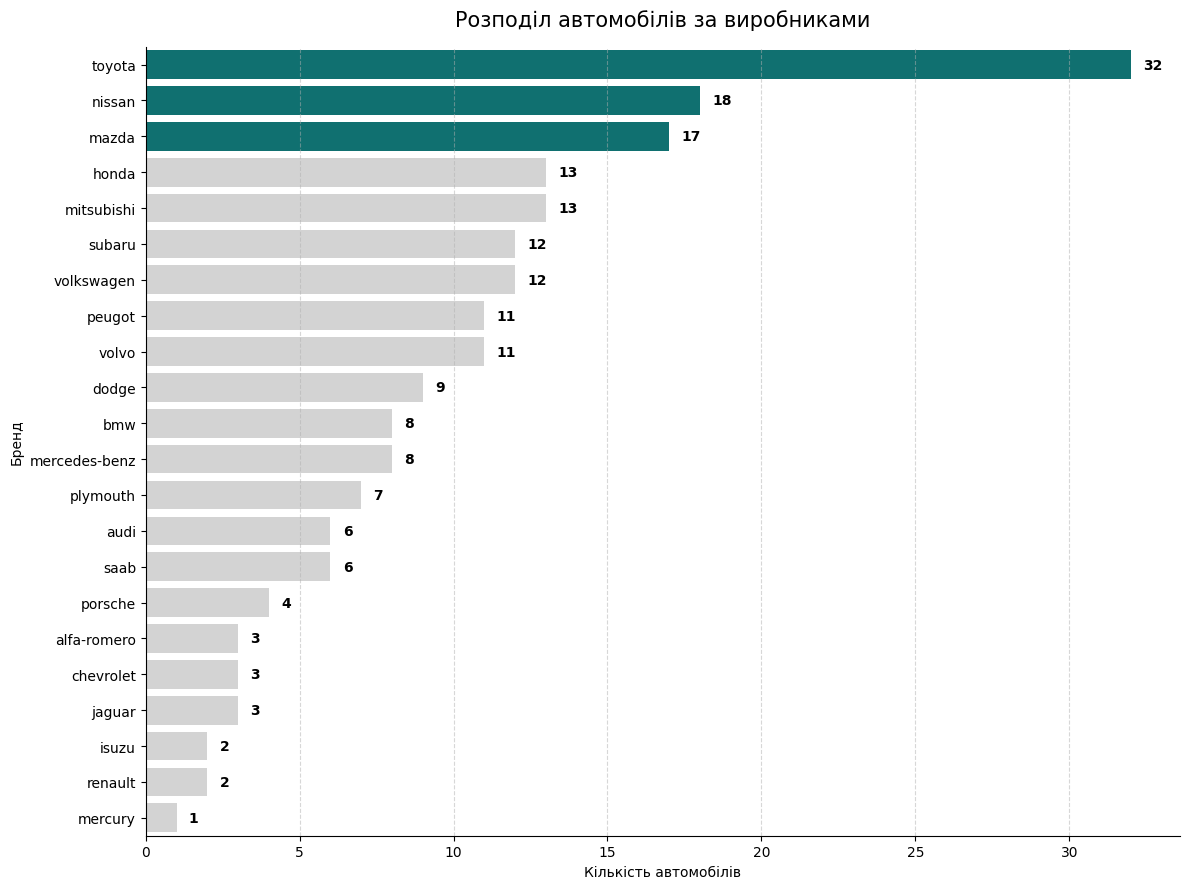

In [ ]:
plt.figure(figsize=(12, 9))

brand_stats = df['make'].value_counts()

my_colors = ['teal' if i < 3 else 'lightgray' for i in range(len(brand_stats))]

ax = sns.barplot(x=brand_stats.values, y=brand_stats.index, palette=my_colors, hue=brand_stats.index, legend=False)

for index, value in enumerate(brand_stats.values):
    ax.text(value + 0.4, index, str(value), color='black', va='center', fontweight='bold', fontsize=10)
    
plt.title('Розподіл автомобілів за виробниками', fontsize=15, pad=15)
plt.xlabel('Кількість автомобілів')
plt.ylabel('Бренд')

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()